# Tarea 3 conjunto de cáncer de mama

In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns

## Parte de la clase

In [177]:
df = pd.read_csv(r'Data/wdbc.data', header=None)
df

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [178]:
print("\n")
print(df.head())
print("\n")
print(df.shape)
print("\n")
print(df.describe())
print("\n")
print(df.info())



         0  1      2      3       4       5        6        7       8   \
0    842302  M  17.99  10.38  122.80  1001.0  0.11840  0.27760  0.3001   
1    842517  M  20.57  17.77  132.90  1326.0  0.08474  0.07864  0.0869   
2  84300903  M  19.69  21.25  130.00  1203.0  0.10960  0.15990  0.1974   
3  84348301  M  11.42  20.38   77.58   386.1  0.14250  0.28390  0.2414   
4  84358402  M  20.29  14.34  135.10  1297.0  0.10030  0.13280  0.1980   

        9   ...     22     23      24      25      26      27      28      29  \
0  0.14710  ...  25.38  17.33  184.60  2019.0  0.1622  0.6656  0.7119  0.2654   
1  0.07017  ...  24.99  23.41  158.80  1956.0  0.1238  0.1866  0.2416  0.1860   
2  0.12790  ...  23.57  25.53  152.50  1709.0  0.1444  0.4245  0.4504  0.2430   
3  0.10520  ...  14.91  26.50   98.87   567.7  0.2098  0.8663  0.6869  0.2575   
4  0.10430  ...  22.54  16.67  152.20  1575.0  0.1374  0.2050  0.4000  0.1625   

       30       31  
0  0.4601  0.11890  
1  0.2750  0.08902  
2  

In [179]:
nombres_columnas = {
0: "ID",
1: "diagnostico",
2: "radio medio",
3: "textura media",
4: "perimetro medio",
5: "area media"
}
df.rename(columns=nombres_columnas, inplace=True)
print(df.columns)

Index([             'ID',     'diagnostico',     'radio medio',
         'textura media', 'perimetro medio',      'area media',
                       6,                 7,                 8,
                       9,                10,                11,
                      12,                13,                14,
                      15,                16,                17,
                      18,                19,                20,
                      21,                22,                23,
                      24,                25,                26,
                      27,                28,                29,
                      30,                31],
      dtype='object')


In [180]:
df['target'] = df['diagnostico'].map({'M': 0, 'B': 1})
df.head(10)

,ID,diagnostico,radio medio,textura media,perimetro medio,area media,6,7,8,9,...,23,24,25,26,27,28,29,30,31,target
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,0
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,0
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,0


In [181]:
df = df.drop(columns=['ID', 'diagnostico'])
print(df.iloc[:10, :4])

   radio medio  textura media  perimetro medio  area media
0        17.99          10.38           122.80      1001.0
1        20.57          17.77           132.90      1326.0
2        19.69          21.25           130.00      1203.0
3        11.42          20.38            77.58       386.1
4        20.29          14.34           135.10      1297.0
5        12.45          15.70            82.57       477.1
6        18.25          19.98           119.60      1040.0
7        13.71          20.83            90.20       577.9
8        13.00          21.82            87.50       519.8
9        12.46          24.04            83.97       475.9


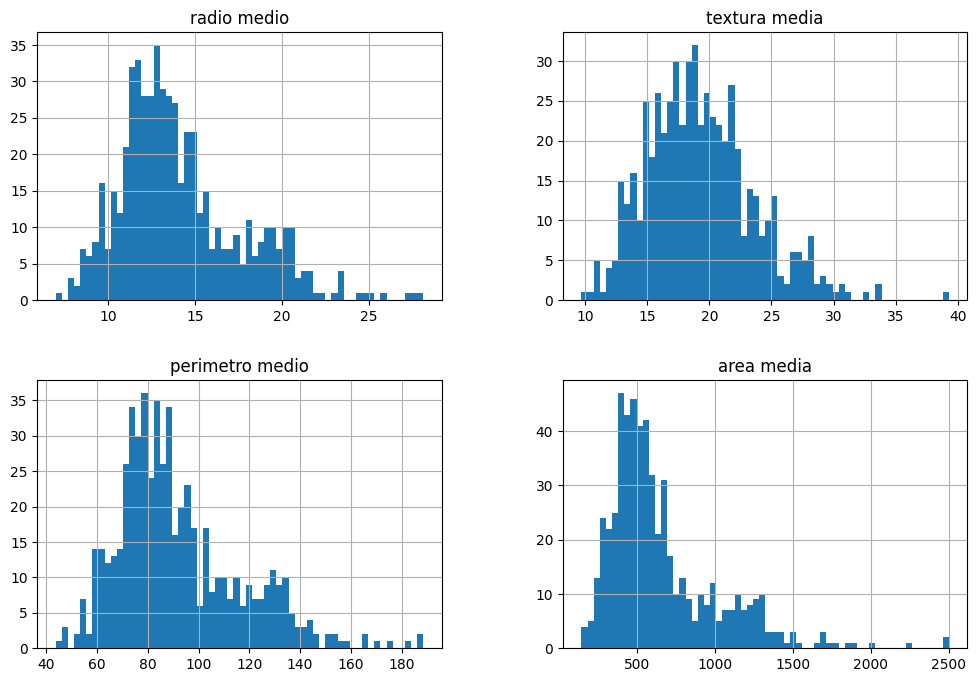

In [182]:
import matplotlib.pyplot as plt
df.iloc[:, :4].hist(figsize=(12, 8), bins=60)
plt.show()

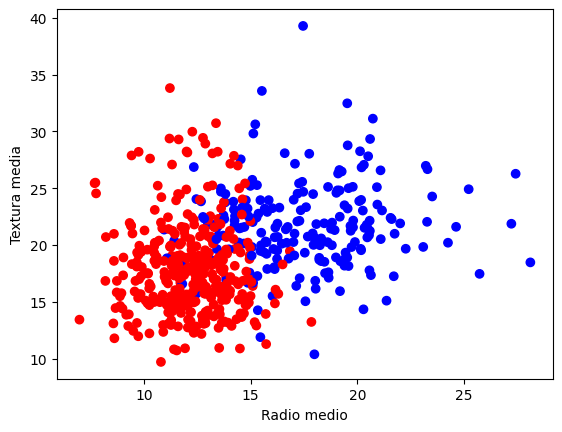

In [183]:
plt.scatter(df['radio medio'], df['textura media'], c=df['target'], cmap='bwr')
plt.xlabel('Radio medio')
plt.ylabel('Textura media')
plt.show()

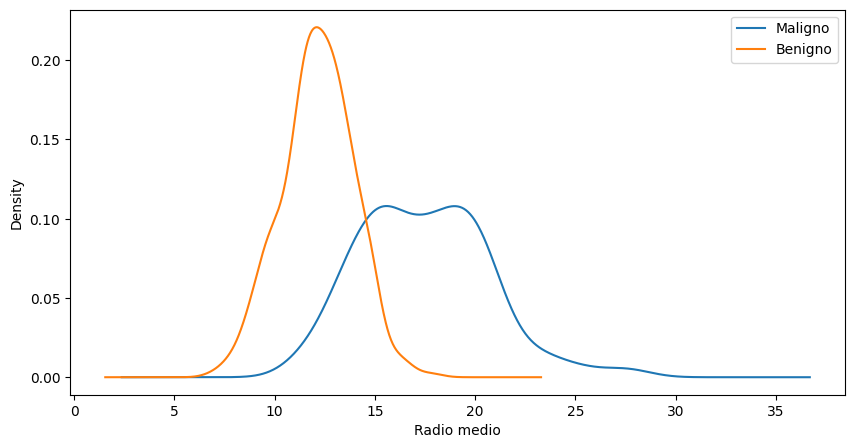

In [184]:
df.groupby  ("target")["radio medio"].plot(kind='kde', figsize=(10, 5))
plt.legend(['Maligno', 'Benigno'], loc='upper right')
plt.xlabel('Radio medio')
plt.show()


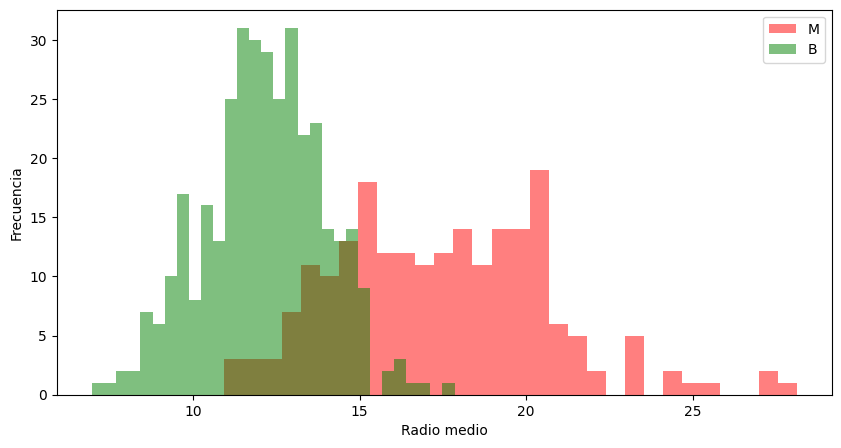

In [185]:
maligno = df[df['target'] == 0] # Clase 'Maligno'
benigno = df[df['target'] == 1] # Clase 'Benigno'
plt.figure(figsize=(10, 5))
plt.hist(maligno['radio medio'], alpha=0.5, label='M', color='red', bins=30)
plt.hist(benigno['radio medio'], alpha=0.5, label='B', color='green', bins=30)
plt.xlabel('Radio medio')
plt.ylabel('Frecuencia')
plt.legend(loc='upper right')
plt.show()

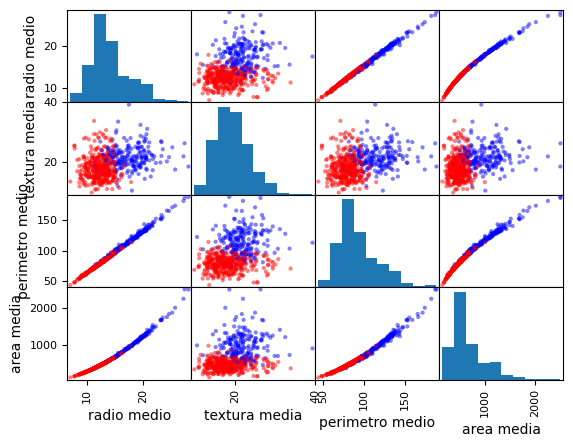

In [186]:
scatter_matrix(df.iloc[:, :4], c=df['target'], cmap='bwr')
plt.show()

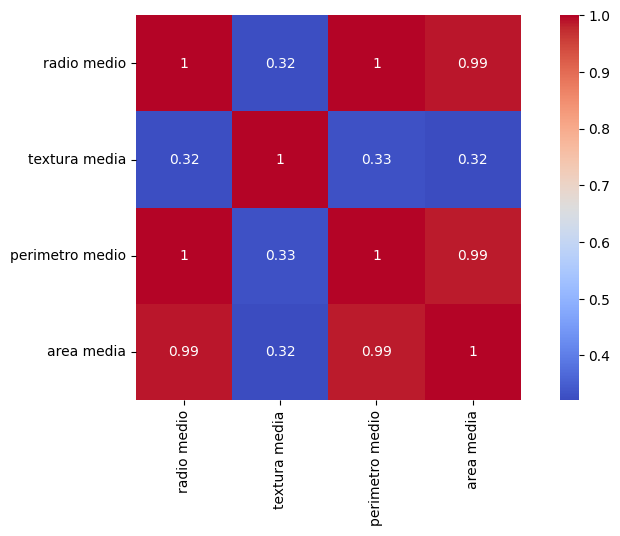

In [187]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.iloc[:, 0:4].corr(), annot=True, square=True, cmap='coolwarm')
plt.show()

In [188]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target # 0 = Maligno, 1 = Benigno
df.head(10)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,0


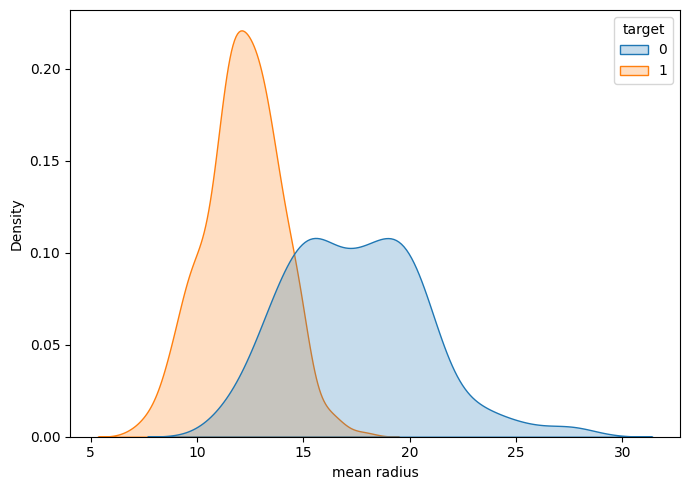

In [189]:
var = 'mean radius'
plt.figure(figsize=(7, 5))
sns.kdeplot(data=df, x=var, hue='target', fill=True, common_norm=False)
plt.xlabel(var)
plt.tight_layout()
plt.show()

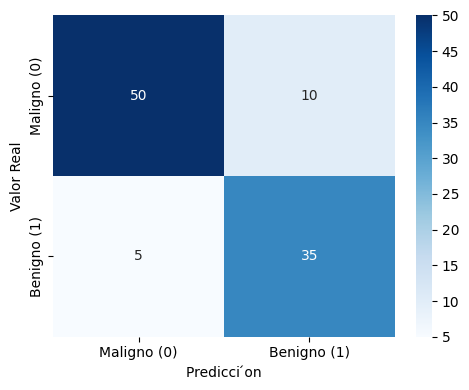

In [190]:
cm = [[50, 10], [5, 35]]
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=['Maligno (0)', 'Benigno (1)'],
yticklabels=['Maligno (0)', 'Benigno (1)'])

plt.xlabel('Predicci ́on')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

## Ejerccio 1 
Elegimos las variables que tengan correlación con target de c<|0.3|, |3|>c<|0.5| y mayor a |0.75|, para ello usamos la gráfica de mapa de calor que usamos en clase y podemos selecionarla que simplemente ver las correlaciones, una vez seleccionados vamos a ver las correlaciones que tenemos. 

La variables elegidas fuero "texture error","mean smoothness", "worst perimeter"

Vamos a usar el DataFrame dado por Scikit-learn

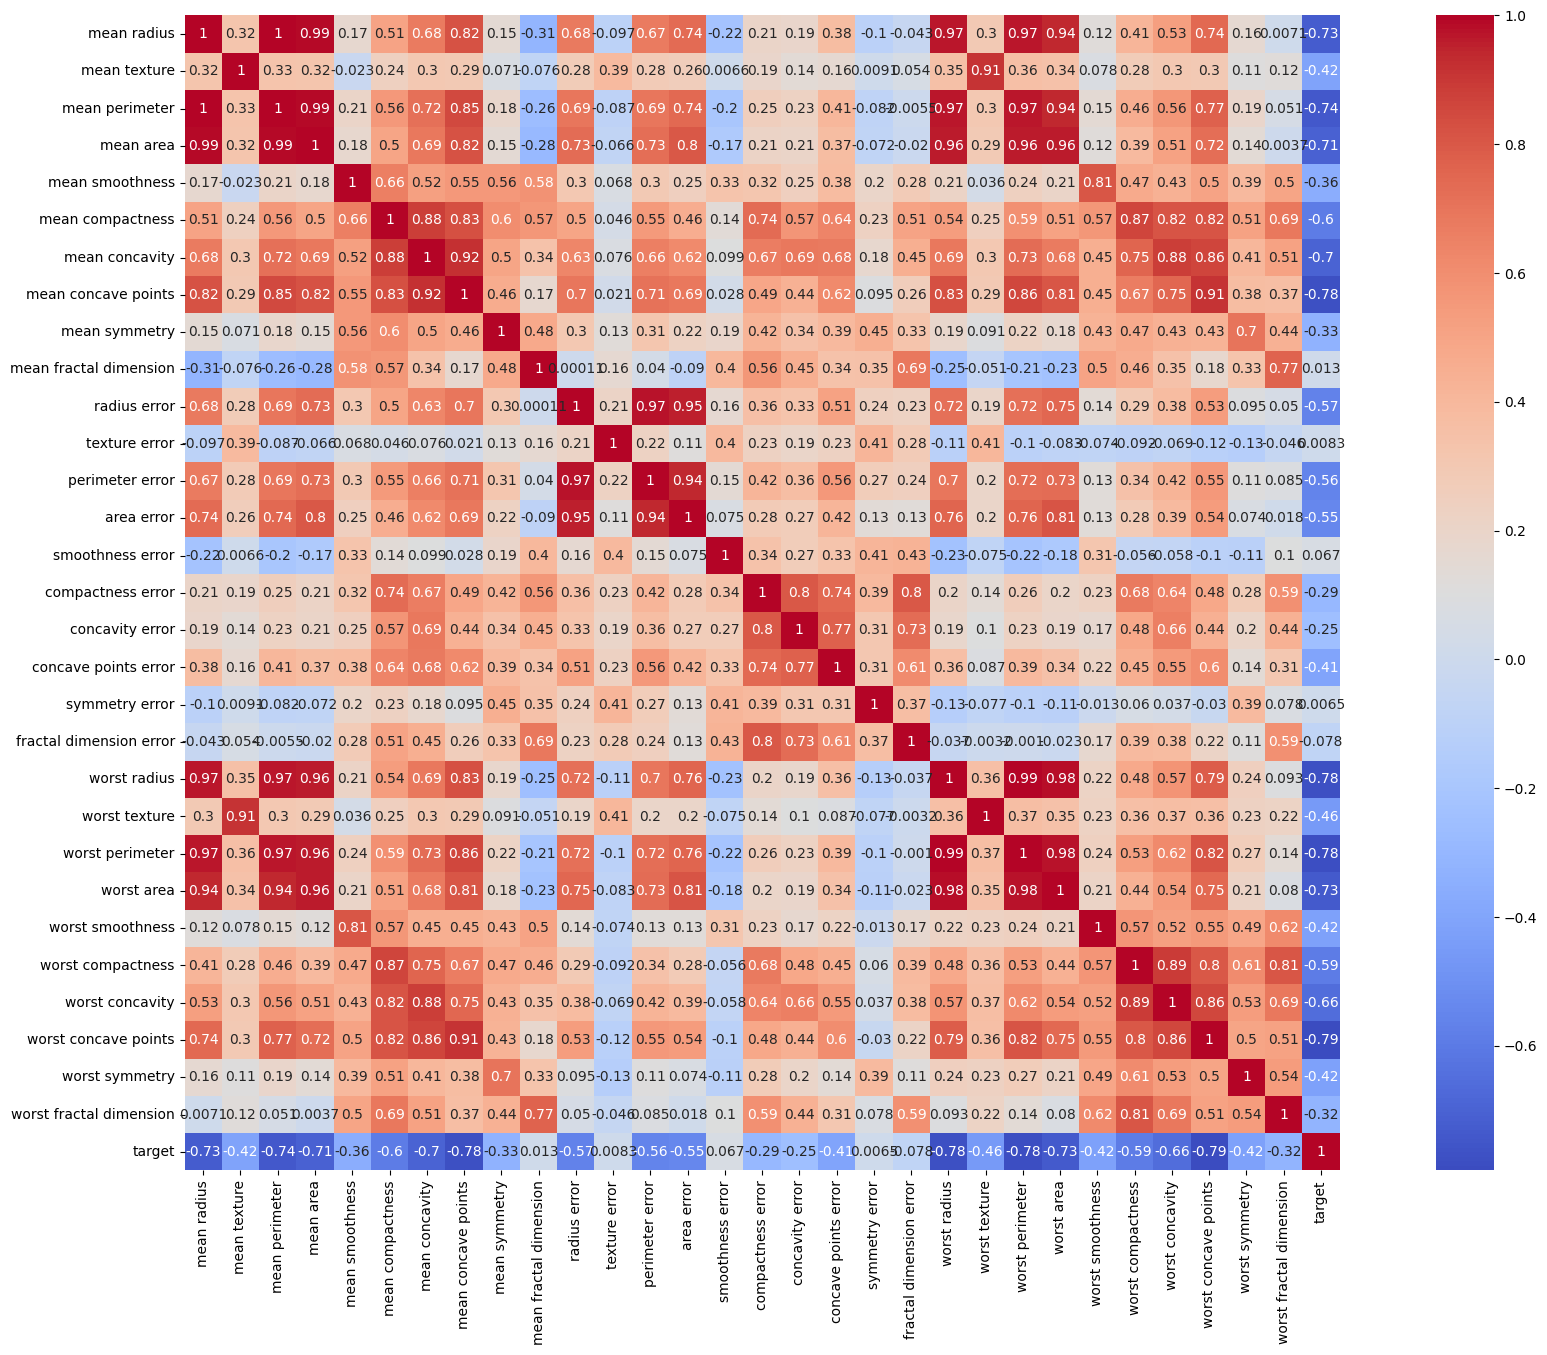

In [191]:
plt.figure(figsize=(25, 15))
sns.heatmap(df.corr(), annot=True, square=True, cmap='coolwarm')
plt.show()

In [192]:
df["texture error"] # Esta tiene correlación de 0.008303

0      0.9053
1      0.7339
2      0.7869
3      1.1560
4      0.7813
        ...  
564    1.2560
565    2.4630
566    1.0750
567    1.5950
568    1.4280
Name: texture error, Length: 569, dtype: float64

In [193]:
df["mean smoothness"] # Esta varible tiene la correlación de -0.358560

0      0.11840
1      0.08474
2      0.10960
3      0.14250
4      0.10030
        ...   
564    0.11100
565    0.09780
566    0.08455
567    0.11780
568    0.05263
Name: mean smoothness, Length: 569, dtype: float64

In [194]:
df["worst perimeter"] # Esta varible tiene la correlación de -0.782914

0      184.60
1      158.80
2      152.50
3       98.87
4      152.20
        ...  
564    166.10
565    155.00
566    126.70
567    184.60
568     59.16
Name: worst perimeter, Length: 569, dtype: float64

In [195]:
df_a_estudiar = df[["texture error","mean smoothness", "worst perimeter","target"]]
df_a_estudiar

,texture error,mean smoothness,worst perimeter,target
0,0.9053,0.11840,184.60,0
1,0.7339,0.08474,158.80,0
2,0.7869,0.10960,152.50,0
3,1.1560,0.14250,98.87,0
4,0.7813,0.10030,152.20,0
...,...,...,...,...
564,1.2560,0.11100,166.10,0
565,2.4630,0.09780,155.00,0
566,1.0750,0.08455,126.70,0
567,1.5950,0.11780,184.60,0


In [196]:
df_a_estudiar.corr()

,texture error,mean smoothness,worst perimeter,target
texture error,1.000000,0.068406,-0.102242,0.008303
mean smoothness,0.068406,1.000000,0.238853,-0.358560
worst perimeter,-0.102242,0.238853,1.000000,-0.782914
target,0.008303,-0.358560,-0.782914,1.000000


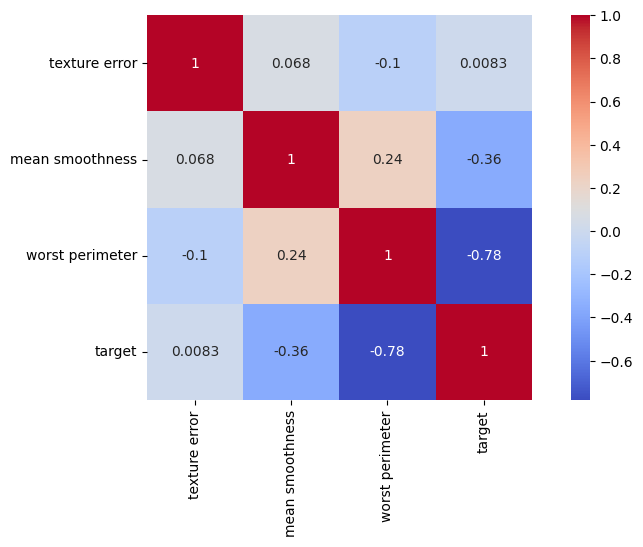

In [197]:
plt.figure(figsize=(10, 5))
sns.heatmap(df_a_estudiar.corr(), annot=True, square=True, cmap='coolwarm')
plt.show()

## Ejercicio 2 
Con la función describe analisamos los datos de manera cuantitativa, podemos observar que aproximadamente, la relación entre media y desviasión estándar tenemos que para texture error es dos veces, en mean smoothness es 6 veces, y para worst perimeter es de 3 veces lo que significa que los datos están dispersos, pero más para el texture erro, y worts perimeter, pero recordemos que tenemos dos variables en target que es lo que nos importa, lo mejor será utilizar un filtrado para ver como se comportan los datos entre benigno o maligno. 

Al realizar la descripción de cada una de benigno o maligno (m = 0 y b = 1), tenemos que los valores estadísticos son similares, desde aquí podemos predecir que será díficil usar texture error y worst perimeter para separar entre benigno o maligno  

In [198]:
df_a_estudiar.describe()

,texture error,mean smoothness,worst perimeter,target
count,569.000000,569.000000,569.000000,569.000000
mean,1.216853,0.096360,107.261213,0.627417
std,0.551648,0.014064,33.602542,0.483918
min,0.360200,0.052630,50.410000,0.000000
25%,0.833900,0.086370,84.110000,0.000000
50%,1.108000,0.095870,97.660000,1.000000
75%,1.474000,0.105300,125.400000,1.000000
max,4.885000,0.163400,251.200000,1.000000


In [199]:
df_a_estudiar[df_a_estudiar["target"] == 0].describe()

,texture error,mean smoothness,worst perimeter,target
count,212.000000,212.000000,212.000000,212.0
mean,1.210915,0.102898,141.370330,0.0
std,0.483178,0.012608,29.457055,0.0
min,0.362100,0.073710,85.100000,0.0
25%,0.892825,0.094010,119.325000,0.0
50%,1.102500,0.102200,138.000000,0.0
75%,1.429250,0.110925,159.800000,0.0
max,3.568000,0.144700,251.200000,0.0


In [200]:
df_a_estudiar[df_a_estudiar["target"] == 1].describe()

,texture error,mean smoothness,worst perimeter,target
count,357.00000,357.000000,357.000000,357.0
mean,1.22038,0.092478,87.005938,1.0
std,0.58918,0.013446,13.527091,0.0
min,0.36020,0.052630,50.410000,1.0
25%,0.79590,0.083060,78.270000,1.0
50%,1.10800,0.090760,86.920000,1.0
75%,1.49200,0.100700,96.590000,1.0
max,4.88500,0.163400,127.100000,1.0


## Ejercicio 3 densidad de kernel (KDE)
Los umbrales gráficados fueron [0.8, 0.13, 130 ], los obtuvimos a base de prueba y error, gráficamos y una vez gráficados los estimamos. 

Lo que podemos notar es que para el texture error, fue el umbral más díficil, ya que realmente da igual si lo ponemos más adelante o más atrás, no hay un valor claro que nos ayude a separarlos. 

Para el mean smoothness es igual de díficil, no hay una clara distinción, a diferencia de worst perimeter, ya que el umbral es más claro, pero eso no significa que sea un buen clasificador de tumores, ya que no los separa al 100%, las gráficas se translapan 

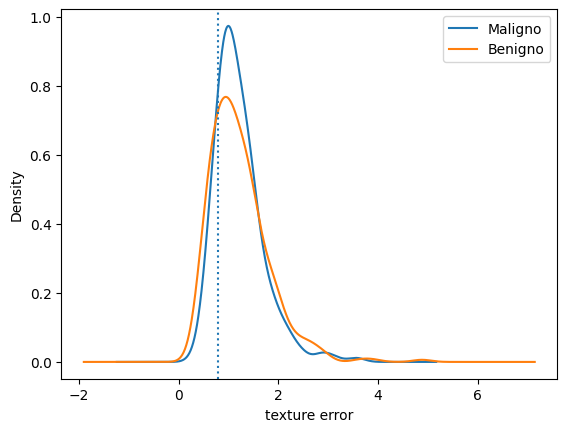

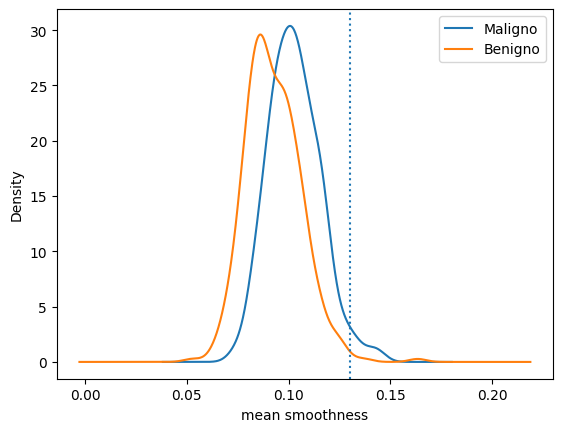

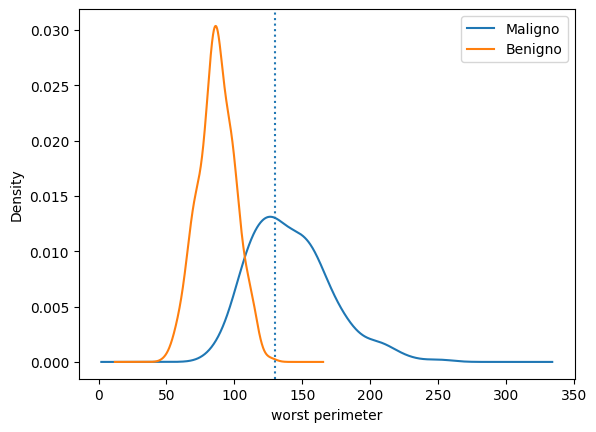

In [225]:
variables = ["texture error","mean smoothness", "worst perimeter"]
umbral = [0.8, 0.13, 130 ]
figsize=(10, 10)
for i in range(3):
    df_a_estudiar.groupby("target")[variables[i]].plot(kind='kde')
    plt.legend(['Maligno', 'Benigno'], loc='best')
    plt.axvline(x=umbral[i], linestyle=":")
    plt.xlabel(f'{variables[i]}')
    plt.show()

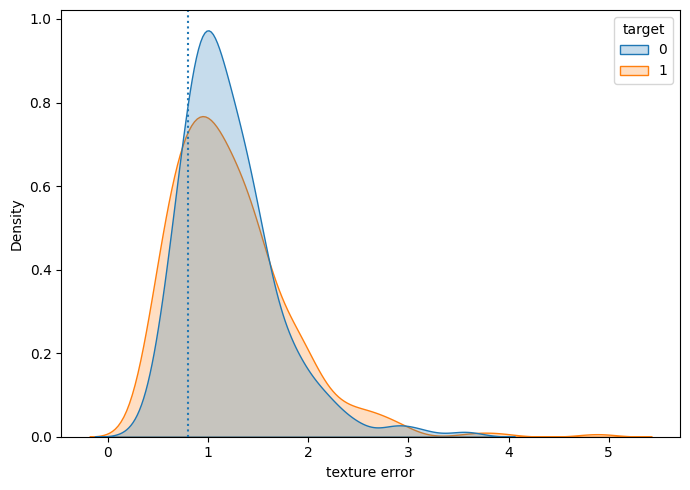

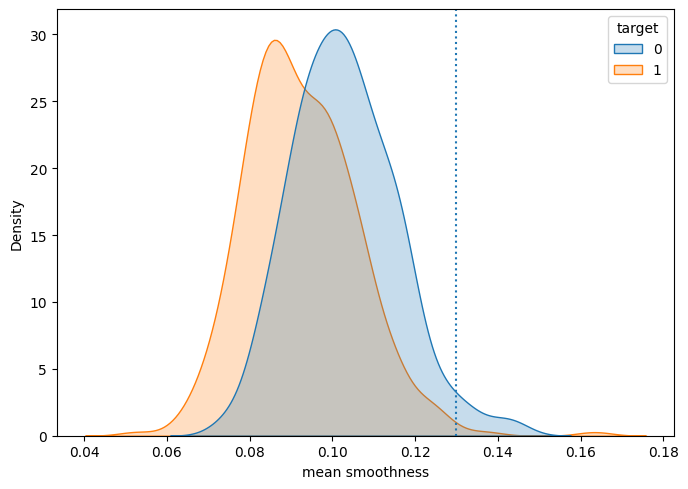

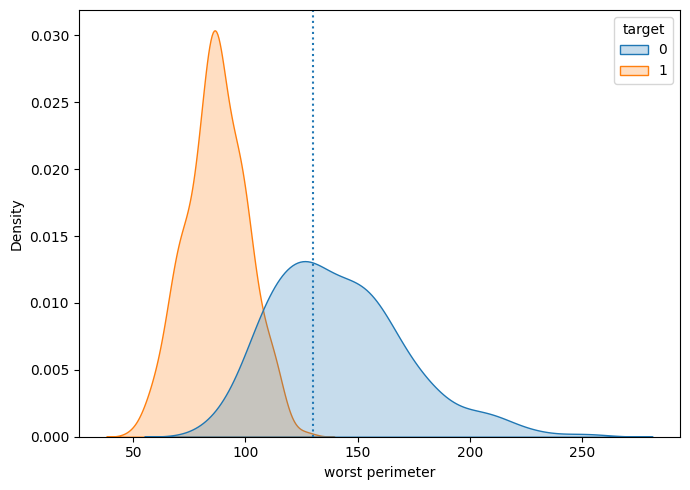

In [226]:
figsize=(10, 10)
for i in range(3):
    var = variables[i]
    
    plt.figure(figsize=(7, 5))
    sns.kdeplot(data=df, x=var, hue='target', fill=True, common_norm=False)
    plt.xlabel(var)
    plt.tight_layout()
    plt.axvline(x=umbral[i], linestyle=":") # Linea del umbral 
    plt.xlabel(f'{variables[i]}')
    plt.show()


## Ejercicio 4 etiquetas de clasificación 

Creamos para cada una de las variables, la clasificación que se da dado los lumbrales que tenemos, vamos a compararlos con con el target original.



In [227]:
df_a_estudiar["pred1"] = (df_a_estudiar["texture error"] < 0.8).astype(int) # la primera parte df["worst perimeter"] < 130 genera valores booleanos
# Nos dice si la condición es verdadera o falta, y astype lo convierte a 0 o 1, también pudimos meternos en problemas haciencido 
# un for, con condicional, if, pero es más rápido y usamos funciones de pandas. 
df_a_estudiar["pred2"] = (df_a_estudiar["mean smoothness"] < 0.13).astype(int)
df_a_estudiar["pred3"] = (df_a_estudiar["worst perimeter"] < 130).astype(int)
df_a_estudiar.iloc[:, :].head(5)

,texture error,mean smoothness,worst perimeter,target,pred1,pred2,pred3
0,0.9053,0.11840,184.60,0,0,1,0
1,0.7339,0.08474,158.80,0,1,1,0
2,0.7869,0.10960,152.50,0,1,1,0
3,1.1560,0.14250,98.87,0,0,0,1
4,0.7813,0.10030,152.20,0,1,1,0


In [240]:
for i in range(3):
    print(f"\n En general tenemos que para {variables[i]} \n", (df_a_estudiar["target"] == df_a_estudiar.iloc[:, i+4]).value_counts())
    #print(df_a_estudiar.iloc[:, i+4].head(5)) Esta linea de código es para ver que estoy haciendo bien. 
    correctos = (df_a_estudiar["target"] ==df_a_estudiar.iloc[:, i+4]).sum()
    incorrectos = (df_a_estudiar["target"] !=df_a_estudiar.iloc[:, i+4]).sum()
    #print(correctos)
    #print(incorrectos)
    P_correctos = (correctos * 100)/569
    P_incorrectos = (incorrectos * 100)/569
    print(f"La variable '{variables[i]}' tuvo un porcentaje de {P_incorrectos} clasificados como incorrectos")
    print(f"La variable '{variables[i]}' tuvo un porcentaje de {P_correctos} clasificados como correctos")
    #print(P_correctos+P_incorrectos)



 En general tenemos que para texture error 
 False    302
True     267
Name: count, dtype: int64
La variable 'texture error' tuvo un porcentaje de 53.07557117750439 clasificados como incorrectos
La variable 'texture error' tuvo un porcentaje de 46.92442882249561 clasificados como correctos

 En general tenemos que para mean smoothness 
 True     361
False    208
Name: count, dtype: int64
La variable 'mean smoothness' tuvo un porcentaje de 36.55536028119508 clasificados como incorrectos
La variable 'mean smoothness' tuvo un porcentaje de 63.44463971880492 clasificados como correctos

 En general tenemos que para worst perimeter 
 True     480
False     89
Name: count, dtype: int64
La variable 'worst perimeter' tuvo un porcentaje de 15.641476274165202 clasificados como incorrectos
La variable 'worst perimeter' tuvo un porcentaje de 84.3585237258348 clasificados como correctos


## Ejercicio 5 comparación 
Vamos a comparar las etiquetas target con nuestras predicciones por cada umbral

Podemos notar que para "texture error","mean smoothness" las etiquetas de target no son tan correctas en comparación con "worst perimeter", esto se debe a nuestro umbral, y a la dispersión de los datos, si los datos de B o M están muy juntos, es díficil hacer una clasificación en esa variable, y entre más dispersos entre M o B será una clasificación más clara. 

In [229]:
df_a_estudiar[["target", "pred1","pred2", 	"pred3"]].head(30)


,target,pred1,pred2,pred3
0,0,0,1,0
1,0,1,1,0
2,0,1,1,0
3,0,0,0,1
4,0,1,1,0
5,0,0,1,1
6,0,1,1,0
7,0,0,1,1
8,0,0,1,1
9,0,0,1,1


## 6 Matriz de confusión

In [236]:
df_a_estudiar["texture_error_evaluación"] = (df_a_estudiar["target"] == df_a_estudiar["pred1"])
df_a_estudiar["mean_smoothness_evaluación"] = (df_a_estudiar["target"] == df_a_estudiar["pred2"])
df_a_estudiar["worst_perimeter_evaluación"] = (df_a_estudiar["target"] == df_a_estudiar["pred3"])
df_a_estudiar

,texture error,mean smoothness,worst perimeter,target,pred1,pred2,pred3,texture_error_evaluación,mean_smoothness_evaluación,worst_perimeter_evaluación
0,0.9053,0.11840,184.60,0,0,1,0,True,False,True
1,0.7339,0.08474,158.80,0,1,1,0,False,False,True
2,0.7869,0.10960,152.50,0,1,1,0,False,False,True
3,1.1560,0.14250,98.87,0,0,0,1,True,True,False
4,0.7813,0.10030,152.20,0,1,1,0,False,False,True
...,...,...,...,...,...,...,...,...,...,...
564,1.2560,0.11100,166.10,0,0,1,0,True,False,True
565,2.4630,0.09780,155.00,0,0,1,0,True,False,True
566,1.0750,0.08455,126.70,0,0,1,1,True,False,False
567,1.5950,0.11780,184.60,0,0,1,0,True,False,True


In [271]:
df_a_estudiar[df_a_estudiar["target"] == 0].iloc[:, 7]

0       True
1      False
2      False
3       True
4      False
       ...  
563     True
564     True
565     True
566     True
567     True
Name: texture_error_evaluación, Length: 212, dtype: bool

In [278]:
for i in range(3):
    print(i)
    print(f"En general tenemos que para '{variables[i]}'  para 0",(df_a_estudiar[df_a_estudiar["target"] == 0].iloc[:, i+7]).astype(int).value_counts())
    print(f"En general tenemos que para '{variables[i]}'  para 1 \n",(df_a_estudiar[df_a_estudiar["target"] == 1].iloc[:, i+7]).astype(int).value_counts())
    

0
En general tenemos que para 'texture error'  para 0 texture_error_evaluación
1    177
0     35
Name: count, dtype: int64
En general tenemos que para 'texture error'  para 1 
 texture_error_evaluación
0    267
1     90
Name: count, dtype: int64
1
En general tenemos que para 'mean smoothness'  para 0 mean_smoothness_evaluación
0    206
1      6
Name: count, dtype: int64
En general tenemos que para 'mean smoothness'  para 1 
 mean_smoothness_evaluación
1    355
0      2
Name: count, dtype: int64
2
En general tenemos que para 'worst perimeter'  para 0 worst_perimeter_evaluación
1    123
0     89
Name: count, dtype: int64
En general tenemos que para 'worst perimeter'  para 1 
 worst_perimeter_evaluación
1    357
Name: count, dtype: int64


# Código previo 
Este apartado es el borrador que usé para esta tarea


In [206]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


## Mapa de calor

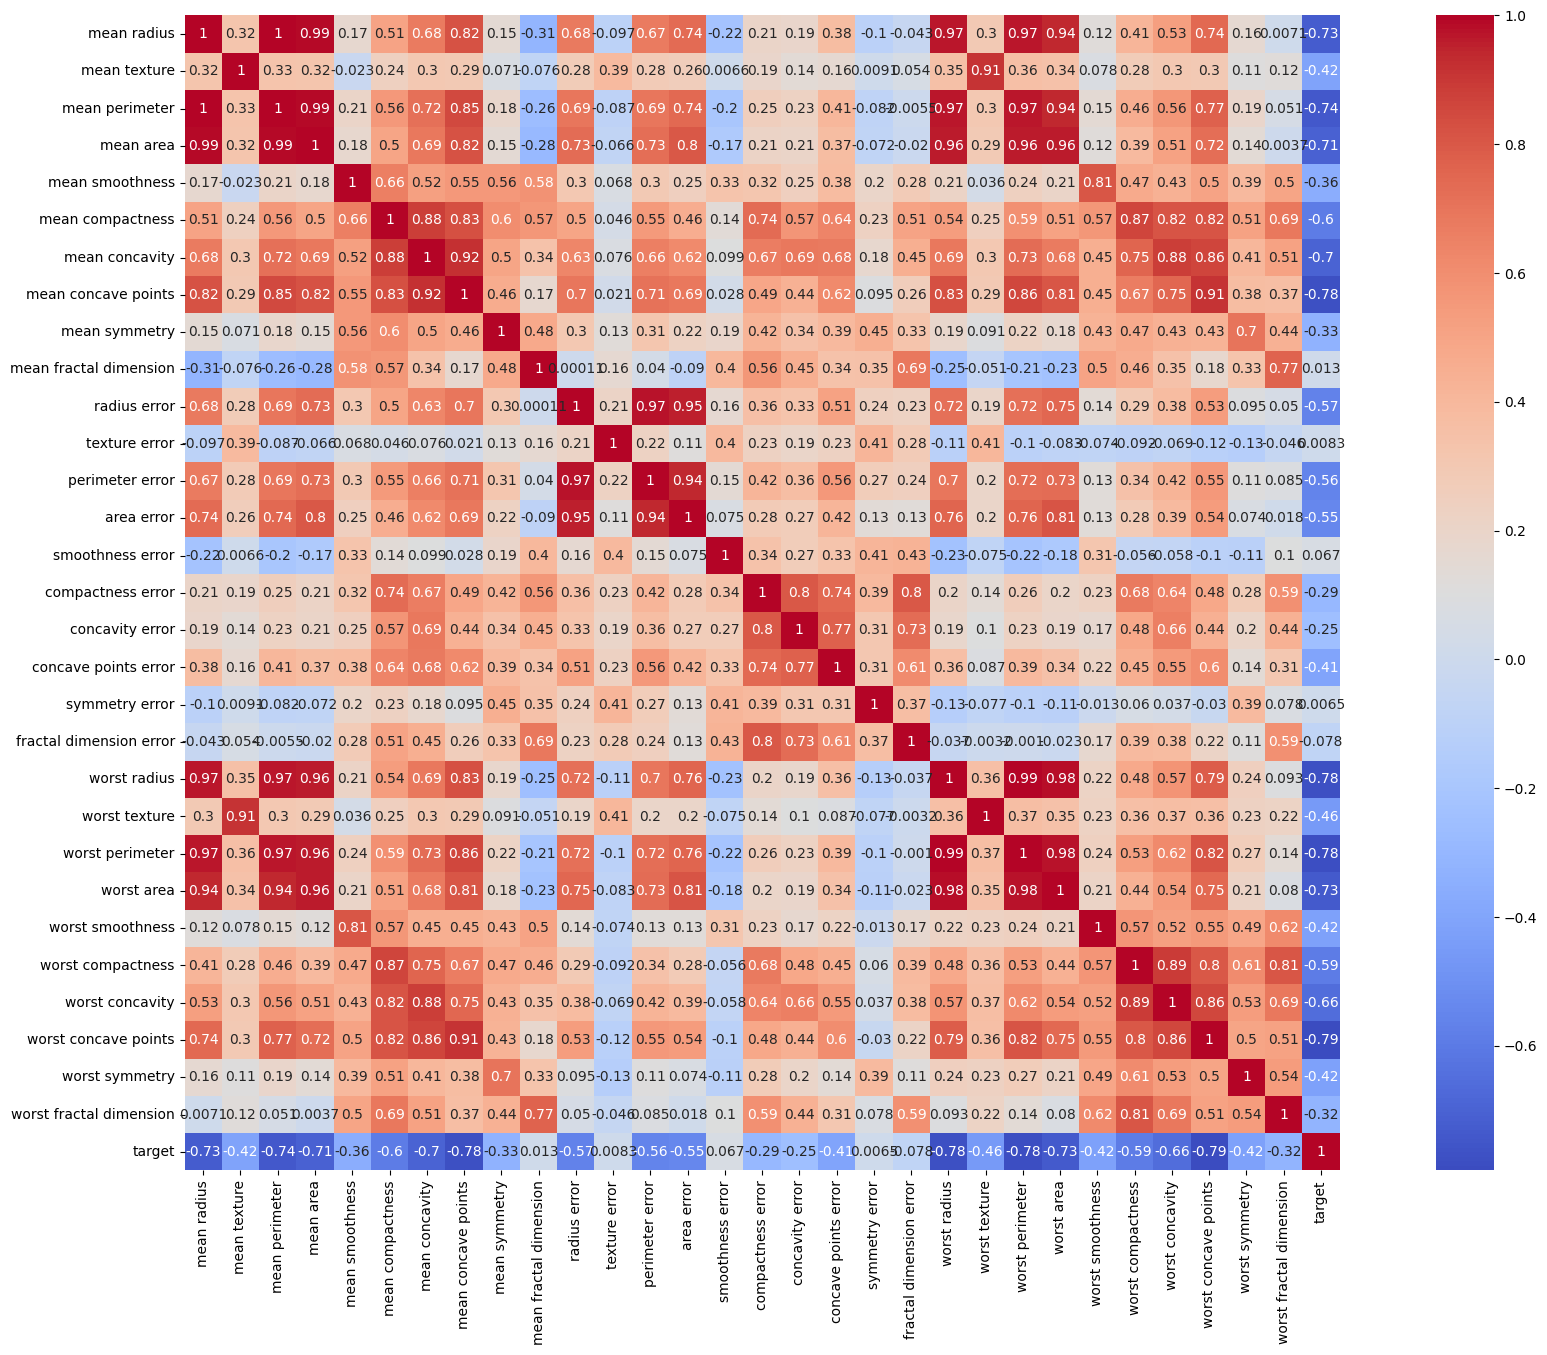

In [207]:
plt.figure(figsize=(25, 15))
sns.heatmap(df.corr(), annot=True, square=True, cmap='coolwarm')
plt.show()

In [208]:
df.corr()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066,-0.730029
mean texture,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205,-0.415185
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019,-0.742636
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738,-0.708984
mean smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316,-0.358560
mean compactness,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382,-0.596534
mean concavity,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930,-0.696360
mean concave points,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661,-0.776614
mean symmetry,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413,-0.330499
mean fractal dimension,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297,0.012838


In [209]:
df["texture error"] # Esta tiene correlación de 0.008303


0      0.9053
1      0.7339
2      0.7869
3      1.1560
4      0.7813
        ...  
564    1.2560
565    2.4630
566    1.0750
567    1.5950
568    1.4280
Name: texture error, Length: 569, dtype: float64

In [210]:
df["mean smoothness"] # Esta varible tiene la correlación de -0.358560

0      0.11840
1      0.08474
2      0.10960
3      0.14250
4      0.10030
        ...   
564    0.11100
565    0.09780
566    0.08455
567    0.11780
568    0.05263
Name: mean smoothness, Length: 569, dtype: float64

In [211]:
df["worst perimeter"] # Esta varible tiene la correlación de -0.782914

0      184.60
1      158.80
2      152.50
3       98.87
4      152.20
        ...  
564    166.10
565    155.00
566    126.70
567    184.60
568     59.16
Name: worst perimeter, Length: 569, dtype: float64

In [212]:
df_a_estudiar = df[["texture error","mean smoothness", "worst perimeter","target"]]
df_a_estudiar

,texture error,mean smoothness,worst perimeter,target
0,0.9053,0.11840,184.60,0
1,0.7339,0.08474,158.80,0
2,0.7869,0.10960,152.50,0
3,1.1560,0.14250,98.87,0
4,0.7813,0.10030,152.20,0
...,...,...,...,...
564,1.2560,0.11100,166.10,0
565,2.4630,0.09780,155.00,0
566,1.0750,0.08455,126.70,0
567,1.5950,0.11780,184.60,0


In [213]:
df_a_estudiar.corr()

,texture error,mean smoothness,worst perimeter,target
texture error,1.000000,0.068406,-0.102242,0.008303
mean smoothness,0.068406,1.000000,0.238853,-0.358560
worst perimeter,-0.102242,0.238853,1.000000,-0.782914
target,0.008303,-0.358560,-0.782914,1.000000


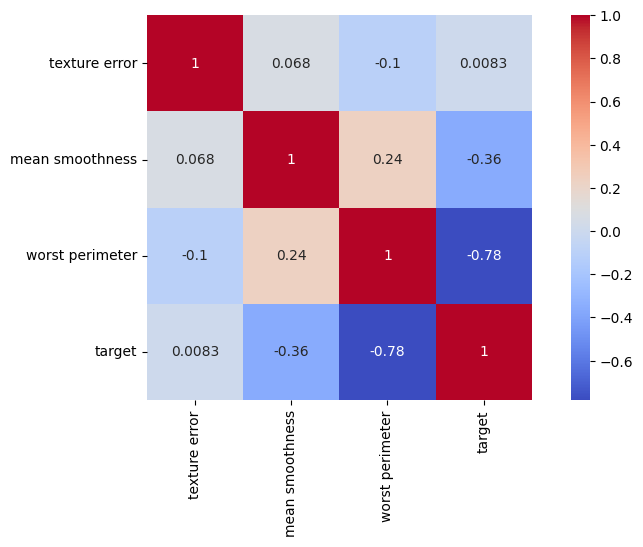

In [214]:
plt.figure(figsize=(10, 5))
sns.heatmap(df_a_estudiar.corr(), annot=True, square=True, cmap='coolwarm')
plt.show()

In [215]:
df_a_estudiar.describe()

,texture error,mean smoothness,worst perimeter,target
count,569.000000,569.000000,569.000000,569.000000
mean,1.216853,0.096360,107.261213,0.627417
std,0.551648,0.014064,33.602542,0.483918
min,0.360200,0.052630,50.410000,0.000000
25%,0.833900,0.086370,84.110000,0.000000
50%,1.108000,0.095870,97.660000,1.000000
75%,1.474000,0.105300,125.400000,1.000000
max,4.885000,0.163400,251.200000,1.000000


texture error


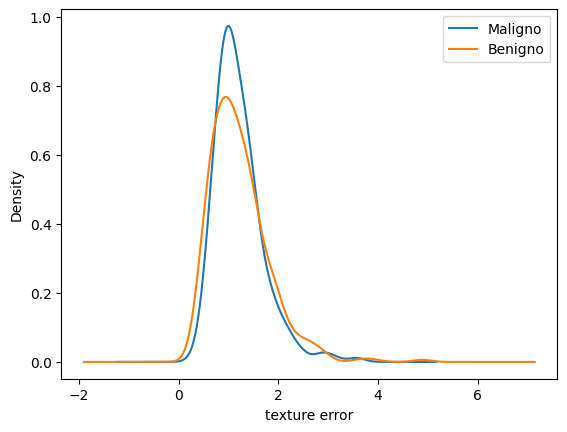

mean smoothness


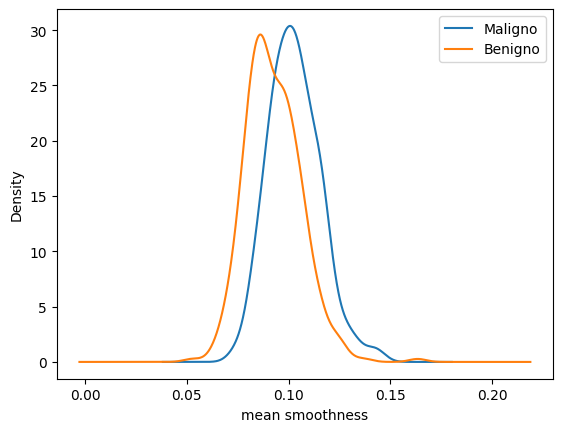

worst perimeter


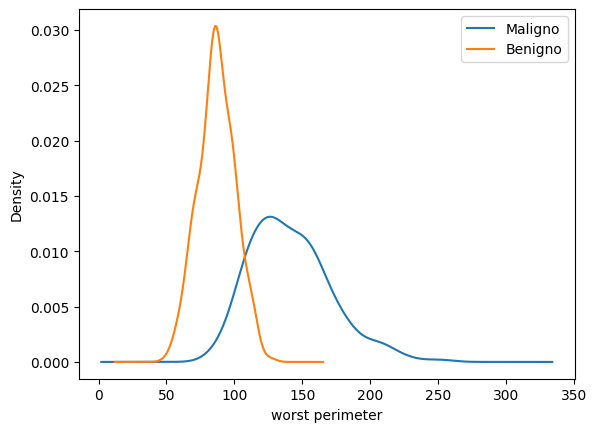

In [216]:
variables = ["texture error","mean smoothness", "worst perimeter"]
figsize=(10, 10)
for i in variables:
    print(i)

    df.groupby("target")[i].plot(kind='kde')
    plt.legend(['Maligno', 'Benigno'], loc='best')
    plt.xlabel(f'{i}')
    plt.show()
